In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.executable)
import seaborn as sns
import re
import string
import warnings
import os
import nltk
import pickle
import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


warnings.filterwarnings('ignore')
plt.style.use('default')
print("√ All libraries imported successfully")
import os
import nltk
import ssl

# Set download directory for nltk data
nltk_data_dir = os.path.join(os.getcwd(), 'nltk_data')
os.makedirs(nltk_data_dir, exist_ok=True)

# Download required nltk datasets
try:
    # Adding SSL fix inside the try block to be safe
    try:
        _create_unverified_https_context = ssl._create_unverified_context
    except AttributeError:
        pass
    else:
        ssl._create_default_https_context = _create_unverified_https_context
        
    nltk.download('punkt', download_dir=nltk_data_dir)
    nltk.download('stopwords', download_dir=nltk_data_dir)
    nltk.data.path.append(nltk_data_dir)
    print("√ NLTK data downloaded successfully")
    
except Exception as e:
    print(f"Error downloading NLTK data: {e}")
    # Final fallback
    nltk.download('punkt')
    nltk.download('stopwords')
  

c:\Users\HP\OneDrive\Desktop\Fake News Detector\venv\Scripts\python.exe
√ All libraries imported successfully
√ NLTK data downloaded successfully


[nltk_data] Downloading package punkt to
[nltk_data]     c:\Users\HP\OneDrive\Desktop\Fake News
[nltk_data]     Detector\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     c:\Users\HP\OneDrive\Desktop\Fake News
[nltk_data]     Detector\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# 2. Load and Explore Dataset

import pandas as pd
import json

# Load JSON dataset

with open("combined_news_dataset_2026.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Keep only required columns

df = df[["title", "text", "label"]]

# Convert labels

df["label"] = df["label"].map({
    "REAL": 1,
    "FAKE": 0
})

# Remove missing values

df = df.dropna(subset=["text", "label"])

print("✓ Dataset Loaded Successfully")
print("Dataset Shape :", df.shape)

display(df.head())

print("\nClass Distribution")
print(df["label"].value_counts())

print("\nMissing Values")
print(df.isnull().sum())

# Text statistics

df["text_length"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().str.len()

print("\nText Length")
print(df["text_length"].describe())

print("\nWord Count")
print(df["word_count"].describe())

✓ Dataset Loaded Successfully
Dataset Shape : (2506, 3)


,title,text,label
0,Pravrdh Introduces Data-Driven White-Label PPC...,Pravrdh helps growing agencies access Google A...,1
1,My Lord and My God: The Living Faith of St. Th...,"Fr. M. Titus Mohan – Every year on July 3, Chr...",1
2,"Blue Line sees 5 lakh, Green Line 1.5 lakh dai...",Kolkata Metro FY25-26 ridership: Blue Line 5 l...,1
3,Terex Announces Quarterly Dividend,"NORWALK, Conn., July 2, 2026 /PRNewswire/ -- T...",1
4,STANDEX ACQUIRES REMAINING INTEREST IN NARAYAN...,"SALEM, N.H., July 2, 2026 /PRNewswire/ -- Stan...",1



Class Distribution
label
1    2382
0     124
Name: count, dtype: int64

Missing Values
title    2
text     0
label    0
dtype: int64

Text Length
count    2506.000000
mean      166.940543
std       100.093924
min         0.000000
25%       101.000000
50%       155.000000
75%       260.000000
max       794.000000
Name: text_length, dtype: float64

Word Count
count    2506.000000
mean       25.889864
std        14.798684
min         0.000000
25%        16.000000
50%        25.000000
75%        38.000000
max        86.000000
Name: word_count, dtype: float64


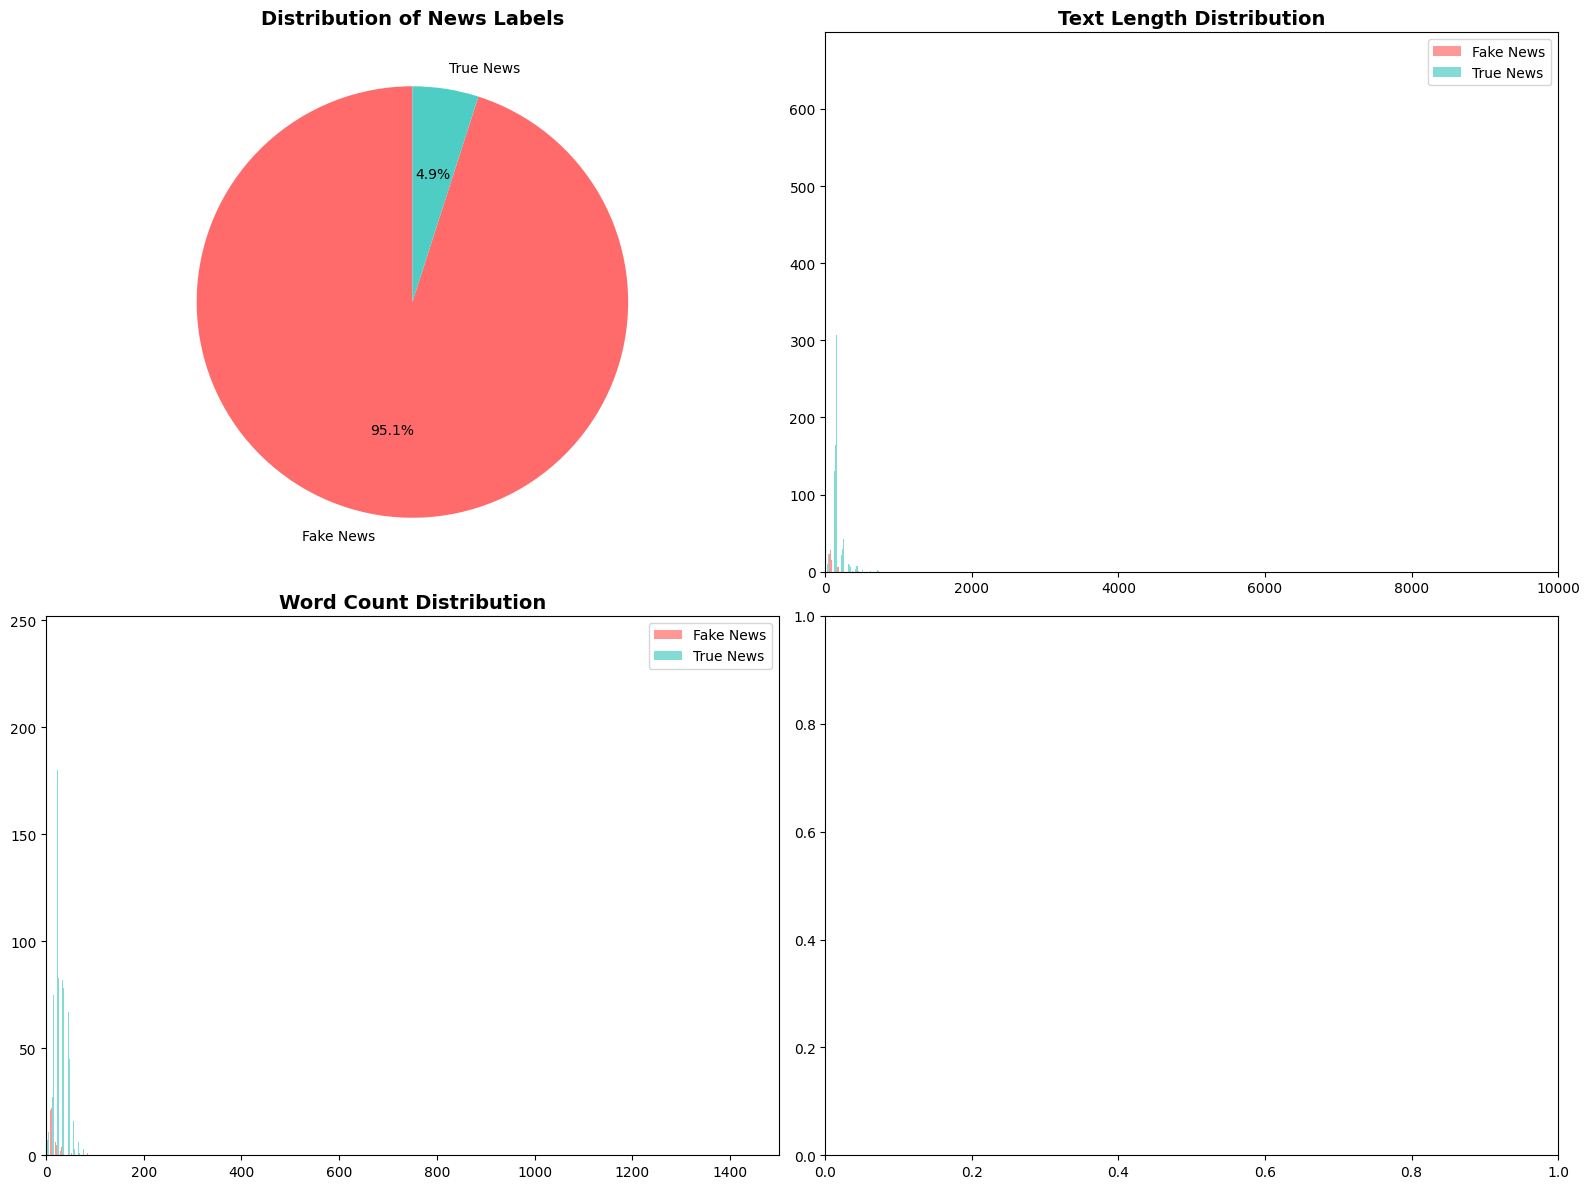

√ NLTK resources loaded successfully
√ Preprocessing function defined and ready


In [5]:
# 3. Data Visualization and Analysis
import matplotlib.pyplot as plt

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['#FF6B6B', '#4ECDC4']

# 1. Class distribution
label_counts = df['label'].value_counts()
axes[0,0].pie(label_counts.values, labels=['Fake News', 'True News'], colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of News Labels', fontsize=14, fontweight='bold')

# 2. Text length distribution
axes[0,1].hist([df[df['label']==0]['text_length'], df[df['label']==1]['text_length']], 
              bins=50, alpha=0.7, label=['Fake News', 'True News'], color=colors)
axes[0,1].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlim(0, 10000)
axes[0,1].legend()

# 3. Word count distribution
axes[1,0].hist([df[df['label']==0]['word_count'], df[df['label']==1]['word_count']], 
              bins=50, alpha=0.7, label=['Fake News', 'True News'], color=colors)
axes[1,0].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlim(0, 1500)
axes[1,0].legend()

# 4. Top 10 News Subjects
if 'subject' in df.columns:
    subject_counts = df['subject'].value_counts().head(10)
    axes[1,1].bar(range(len(subject_counts)), subject_counts.values, color='skyblue')
    axes[1,1].set_title('Top 10 News Subjects', fontsize=14, fontweight='bold')
    axes[1,1].set_xticks(range(len(subject_counts)))
    axes[1,1].set_xticklabels(subject_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()
# 4. Text Preprocessing with Fixed NLTK Implementation

# Initialize preprocessing tools with error handling
try:
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    print("√ NLTK resources loaded successfully")
except LookupError:
    print("! NLTK data not found, using alternative approach...")
    # Fallback: Define basic stopwords manually (from Image 1000118740)
    stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once'])

def preprocess_text(text):
    """
    Comprehensive text preprocessing function with error handling
    """
    if pd.isna(text) or text == '':
        return ''
    
    try:
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove special characters and digits but keep spaces
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        # Tokenize using NLTK if available, otherwise split by space
        try:
            tokens = word_tokenize(text)
        except:
            tokens = text.split()
            
        # Remove stopwords and short words
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        
        # Stemming
        try:
            tokens = [stemmer.stem(word) for word in tokens]
        except:
            # If stemming fails, use original tokens
            pass
            
        return ' '.join(tokens)
        
    except Exception as e:
        print(f"Error processing text: {e}")
        return ''

print("√ Preprocessing function defined and ready")

In [6]:
# 4. Text Preprocessing

print("Preprocessing text data...")
print(f"Processing {len(df)} articles...")

# Remove missing values
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str)

batch_size = 1000
processed_texts = []

for i in range(0, len(df), batch_size):
    batch_end = min(i + batch_size, len(df))

    batch = df['text'].iloc[i:batch_end].apply(preprocess_text)

    processed_texts.extend(batch.tolist())

    print(f"Processed {batch_end}/{len(df)} articles", end="\r")

df['processed_text'] = processed_texts

# Remove empty processed texts
df = df[df['processed_text'].str.strip() != ""]

print("\n✅ Text preprocessing completed successfully")

print("=" * 60)
print("Original:")
print(df['text'].iloc[0][:200])

print("\nProcessed:")
print(df['processed_text'].iloc[0][:200])

print("=" * 60)

Preprocessing text data...
Processing 2506 articles...
Processed 2506/2506 articles
✅ Text preprocessing completed successfully
Original:
Pravrdh helps growing agencies access Google Ads-certified PPC experts, AI-powered campaign optimization, and white-label paid ads management. for agency growth

Processed:
pravrdh help grow agenc access googl ad certifi ppc expert power campaign optim white label paid ad manag agenc growth


In [7]:
# 5. Feature Extraction

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Remove empty texts
df_clean = df[df['processed_text'].str.strip().str.len() > 0].copy()

print(f"Cleaned dataset size: {len(df_clean)}")

# Features & Labels
X = df_clean['processed_text']
y = df_clean['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

# Transform Data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nDataset Split Information")
print("="*40)
print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
print("TF-IDF Features  :", X_train_tfidf.shape[1])
print("Training Distribution:")
print(y_train.value_counts())
print("\nTesting Distribution:")
print(y_test.value_counts())

Cleaned dataset size: 2267

Dataset Split Information
Training samples : 1813
Testing samples  : 454
TF-IDF Features  : 5000
Training Distribution:
label
1    1714
0      99
Name: count, dtype: int64

Testing Distribution:
label
1    429
0     25
Name: count, dtype: int64


In [8]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

print("Creating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # Better vocabulary
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"✅ TF-IDF feature matrix: {X_train_tfidf.shape}")
print(f"✅ Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

feature_names = tfidf_vectorizer.get_feature_names_out()

print("\nTop Sample Features:")
print(feature_names[:20])

Creating TF-IDF features...
✅ TF-IDF feature matrix: (1813, 5191)
✅ Number of features: 5191

Top Sample Features:
['abdul' 'aberdeen' 'aberdeen assum' 'abil' 'abil stage' 'aboard' 'abrdn'
 'abrdn aberdeen' 'abuja' 'abus' 'abuzz' 'academ' 'academi' 'acceler'
 'acceler demand' 'acceler major' 'accent' 'accept' 'access'
 'access homeland']


In [9]:
from imblearn.over_sampling import SMOTE

print("Balancing training data using SMOTE...")

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_tfidf,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Balancing training data using SMOTE...
Before SMOTE:
label
1    1714
0      99
Name: count, dtype: int64

After SMOTE:
label
1    1714
0    1714
Name: count, dtype: int64


In [10]:
# 6. Model Training and Evaluation

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Models
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": CalibratedClassifierCV(
        LinearSVC(random_state=42),
        cv=3
    )
}

results = {}
trained_models = {}

print("Training Models...")
print("=" * 60)

for name, model in models.items():

    print(f"\nTraining {name}...")

    try:

        model.fit(X_train_balanced, y_train_balanced)

        y_pred = model.predict(X_test_tfidf)
        y_prob = model.predict_proba(X_test_tfidf)[:,1]

        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        cv = cross_val_score(
            model,
            X_train_balanced,
            y_train_balanced,
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )

        results[name] = {
            "accuracy": accuracy,
            "auc_score": auc,
            "cv_mean": cv.mean(),
            "cv_std": cv.std(),
            "predictions": y_pred,
            "probabilities": y_prob
        }

        trained_models[name] = model

        print(f"Accuracy : {accuracy:.4f}")
        print(f"AUC      : {auc:.4f}")
        print(f"CV Mean  : {cv.mean():.4f}")

    except Exception as e:

        print(f"{name} Failed : {e}")

print("\nTraining Completed.")

best_model_name = max(results, key=lambda x: results[x]["accuracy"])

print("\nBest Model :", best_model_name)
print("Accuracy   :", results[best_model_name]["accuracy"])

Training Models...

Training Naive Bayes...
Accuracy : 0.9581
AUC      : 0.9556
CV Mean  : 0.9644

Training Logistic Regression...
Accuracy : 0.9780
AUC      : 0.9524
CV Mean  : 0.9947

Training Random Forest...
Accuracy : 0.9581
AUC      : 0.9372
CV Mean  : 0.9924

Training SVM...
Accuracy : 0.9670
AUC      : 0.9393
CV Mean  : 0.9980

Training Completed.

Best Model : Logistic Regression
Accuracy   : 0.9779735682819384


In [11]:
# 7. Model Performance Comparison

performance_data = []

for name, metrics in results.items():
    performance_data.append({
        "Model": name,
        "Accuracy": round(metrics["accuracy"], 4),
        "AUC Score": round(metrics["auc_score"], 4),
        "CV Mean": round(metrics["cv_mean"], 4),
        "CV Std": round(metrics["cv_std"], 4)
    })

results_df = pd.DataFrame(performance_data)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\nModel Performance Summary")
print("=" * 70)
print(results_df)
print("=" * 70)


Model Performance Summary
                 Model  Accuracy  AUC Score  CV Mean  CV Std
0  Logistic Regression    0.9780     0.9524   0.9947  0.0014
1                  SVM    0.9670     0.9393   0.9980  0.0011
2          Naive Bayes    0.9581     0.9556   0.9644  0.0072
3        Random Forest    0.9581     0.9372   0.9924  0.0052


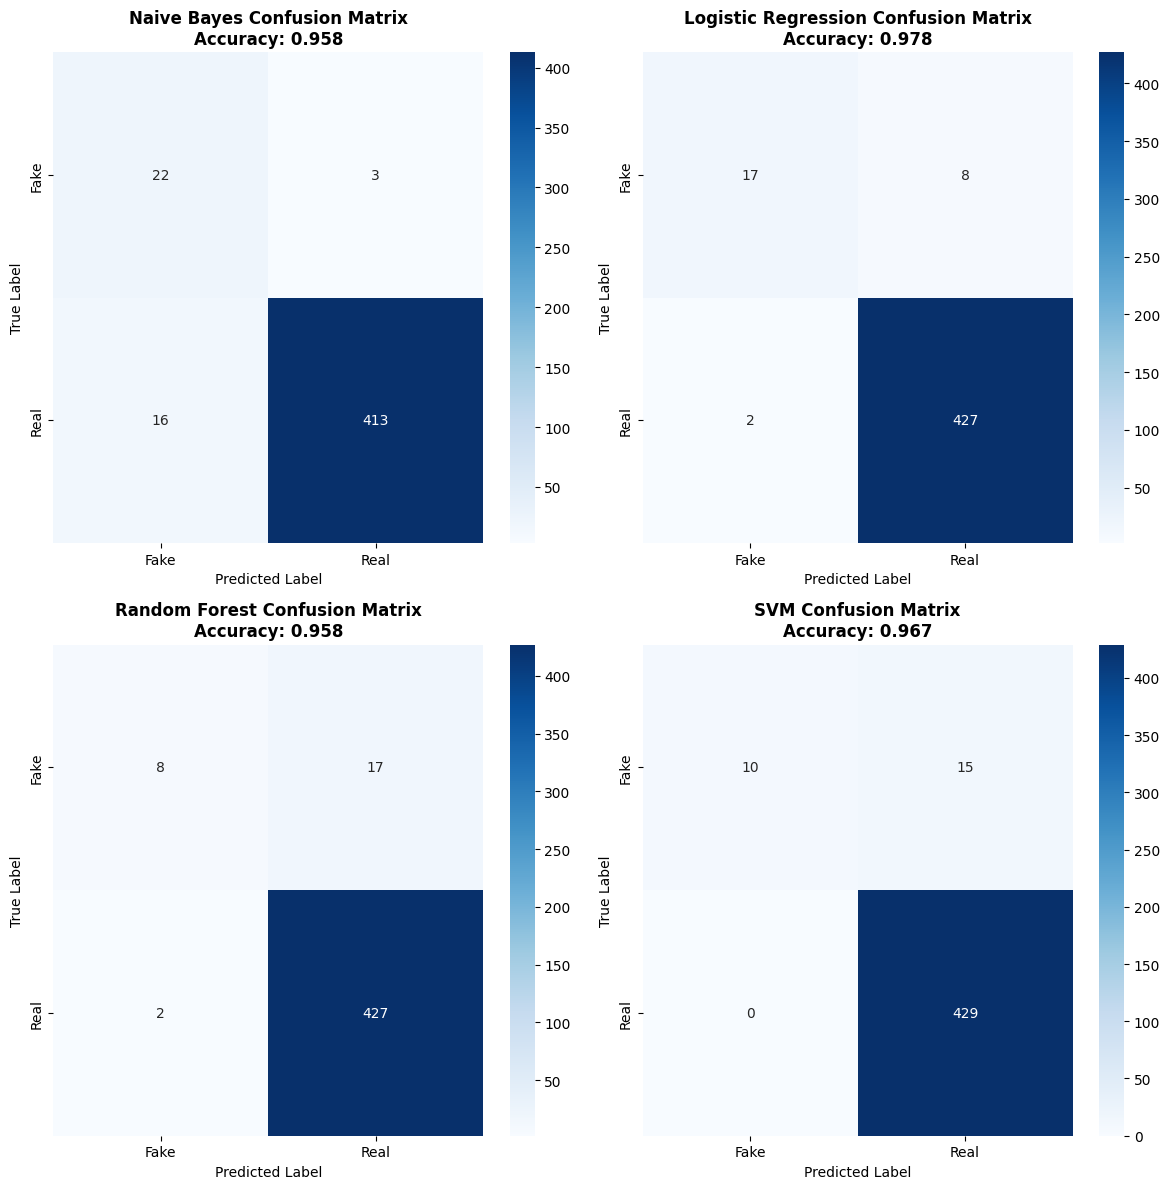

In [12]:
# 8. Confusion Matrices

if results and len(results) > 0:
    # Calculate number of subplots needed
    n_models = len(trained_models)
    n_cols = 2
    n_rows = (n_models + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
        
    for idx, (name, model) in enumerate(trained_models.items()):
        row, col = idx // n_cols, idx % n_cols
        
        cm = confusion_matrix(y_test, results[name]['predictions'])
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                    xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
        axes[row, col].set_title(f"{name} Confusion Matrix\nAccuracy: {results[name]['accuracy']:.3f}", 
                                fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Predicted Label')
        axes[row, col].set_ylabel('True Label')
        
    # Hide empty subplots if any
    for idx in range(len(trained_models), n_rows * n_cols):
        row, col = idx // n_cols, idx % n_cols
        axes[row, col].set_visible(False)
        
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No models available for confusion matrix visualization")

In [13]:
# 9. Detailed Classification Reports & Results DataFrame

if results:
    # Create results dataframe for saving later
    results_list = []
    for model_name, metrics in results.items():
        results_list.append({
            'model': model_name,
            'accuracy': metrics['accuracy'],
            'auc_score': metrics.get('auc_score', 0),
            'precision': metrics.get('precision', 0),
            'recall': metrics.get('recall', 0),
            'f1_score': metrics.get('f1_score', 0),
            'training_time': metrics.get('training_time', 0)
        })
    results_df = pd.DataFrame(results_list)
    print("✅ Results DataFrame created (ready for saving in section 10)")
    print(results_df.round(4).to_string(index=False))
    print()

    # Print detailed classification reports
    for name in results.keys():
        print(f"\n{'='*60}")
        print(f"📊 CLASSIFICATION REPORT FOR {name.upper()}")
        print(f"{'='*60}")
        
        try:
            report = classification_report(y_test, results[name]['predictions'],
                                        target_names=['Fake News', 'True News'],
                                        output_dict=True)
            
            # Update results_df with detailed metrics
            if name in results_df['model'].values:
                idx = results_df[results_df['model'] == name].index[0]
                results_df.loc[idx, 'precision'] = report['weighted avg']['precision']
                results_df.loc[idx, 'recall'] = report['weighted avg']['recall']
                results_df.loc[idx, 'f1_score'] = report['weighted avg']['f1-score']
            
            # Create a formatted table
            print(f"\nOverall Accuracy: {results[name]['accuracy']:.4f}")
            print(f"AUC Score: {results[name]['auc_score']:.4f}")
            print(f"\nDetailed Metrics:")
            print("-" * 60)
            print(f"{'Class':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
            print("-" * 60)
            
            for label in ['Fake News', 'True News']:
                precision = report[label]['precision']
                recall = report[label]['recall']
                f1 = report[label]['f1-score']
                support = report[label]['support']
                print(f"{label:<12} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {support:<10.0f}")
                
            print("-" * 60)
            macro_avg = report['macro avg']
            print(f"{'Macro Avg':<12} {macro_avg['precision']:<10.4f} {macro_avg['recall']:<10.4f} {macro_avg['f1-score']:<10.4f}")
            
            weighted_avg = report['weighted avg']
            print(f"{'Weighted Avg':<12} {weighted_avg['precision']:<10.4f} {weighted_avg['recall']:<10.4f} {weighted_avg['f1-score']:<10.4f}")
            
        except Exception as e:
            print(f"Error generating report for {name}: {e}")
            print(classification_report(y_test, results[name]['predictions'],
                                     target_names=['Fake News', 'True News']))
    
    # Show final results_df
    print(f"\n{'='*70}")
    print("📋 FINAL RESULTS SUMMARY")
    print(f"{'='*70}")
    print(results_df.sort_values('accuracy', ascending=False).round(4).to_string(index=False))
    
else:
    print("⚠️ No results available for classification reports")

✅ Results DataFrame created (ready for saving in section 10)
              model  accuracy  auc_score  precision  recall  f1_score  training_time
        Naive Bayes    0.9581     0.9556          0       0         0              0
Logistic Regression    0.9780     0.9524          0       0         0              0
      Random Forest    0.9581     0.9372          0       0         0              0
                SVM    0.9670     0.9393          0       0         0              0


📊 CLASSIFICATION REPORT FOR NAIVE BAYES
Error generating report for Naive Bayes: Invalid value '0.969999855089265' for dtype 'int64'
              precision    recall  f1-score   support

   Fake News       0.58      0.88      0.70        25
   True News       0.99      0.96      0.98       429

    accuracy                           0.96       454
   macro avg       0.79      0.92      0.84       454
weighted avg       0.97      0.96      0.96       454


📊 CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
Err

In [14]:
# 10. Model Persistence and Saving (Fixed for Flask App)
import os
import joblib
import json
import pandas as pd

if results and trained_models:
    try:
        # 1. Create models directory
        if not os.path.exists('models'):
            os.makedirs('models')
            print("√ Models directory created")

        # 2. Get best model info
        best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
        best_model_obj = trained_models[best_model_name]
        
        # 3. SAVE THE MODEL (Sabse Zaruri)
        joblib.dump(best_model_obj, 'models/best_fake_news_model.pkl')
        print(f"√ Best model ({best_model_name}) saved as 'models/best_fake_news_model.pkl'")

        # 4. SAVE THE VECTORIZER (Iske bina website news nahi pehchanegi)
        joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
        print("√ TF-IDF Vectorizer saved as 'models/tfidf_vectorizer.pkl'")

        # 5. Save results_df if exists
        if 'results_df' in locals() or 'results_df' in globals():
            results_df.to_csv('models/model_performance_results.csv', index=False)
            print("√ Performance results saved")

        # 6. Save metadata
        metadata = {
            'best_model': best_model_name,
            'best_accuracy': float(results[best_model_name]['accuracy']),
            'dataset_size': len(df_clean),
            'features_count': X_train_tfidf.shape[1],
            'training_date': pd.Timestamp.now().isoformat()
        }
        with open('models/model_metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)

        print("\n" + "="*60)
        print("🎉 ALL COMPONENTS SAVED! Now your website will work perfectly.")
        print("="*60)

    except Exception as e:
        print(f"❌ Error saving models: {e}")
else:
    print("⚠️ No models to save. Please run the training cell first.")

√ Best model (Logistic Regression) saved as 'models/best_fake_news_model.pkl'
√ TF-IDF Vectorizer saved as 'models/tfidf_vectorizer.pkl'
√ Performance results saved

🎉 ALL COMPONENTS SAVED! Now your website will work perfectly.


In [15]:
# Create a DataFrame to compare model performances
results_data = []
for name, metrics in results.items():
    results_data.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'AUC Score': metrics['auc_score'],
        'CV Mean': metrics['cv_mean'],
        'CV Std': metrics['cv_std']
    })

results_df = pd.DataFrame(results_data)
results_df = pd.DataFrame(results_data, columns=['Model', 'Accuracy', 'AUC Score', 'CV Mean', 'CV Std'])
if 'Accuracy' in results_df.columns:
    results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("√ Results DataFrame created successfully:")
display(results_df)

√ Results DataFrame created successfully:


,Model,Accuracy,AUC Score,CV Mean,CV Std
1,Logistic Regression,0.977974,0.952448,0.994750,0.001427
3,SVM,0.966960,0.939301,0.997958,0.001091
0,Naive Bayes,0.958150,0.955618,0.964413,0.007181
2,Random Forest,0.958150,0.937249,0.992416,0.005167


In [16]:
# 11. Prediction Function and Testing

def predict_news(text, model=None, vectorizer=None, preprocess_func=None):
    """
    Predict whether a news article is fake or real
    
    Args:
        text (str): The news text to classify
        model: Trained model (if None, loads from file)
        vectorizer: TF-IDF vectorizer (if None, loads from file)
        preprocess_func: Preprocessing function (if None, loads from file)
        
    Returns:
        dict: Prediction results with label, probability, and confidence
    """
    
    try:
        # Load model and vectorizer if not provided (Image 1000118758 logic)
        if model is None:
            import joblib
            model = joblib.load('models/best_fake_news_model.pkl')
        if vectorizer is None:
            import joblib
            vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
        if preprocess_func is None:
            import pickle
            with open('models/preprocessing_function.pkl', 'rb') as f:
                preprocess_func = pickle.load(f)
                
        # Preprocess the text using our custom function
        processed_text = preprocess_func(text)
        
        # Check if text is valid after preprocessing
        if not processed_text or len(processed_text.strip()) == 0:
            return {
                'error': 'Text could not be processed or is empty after preprocessing',
                'prediction': 'UNKNOWN',
                'confidence': 0.0
            }
            
        # Vectorize the text using the trained TF-IDF vectorizer
        text_vector = vectorizer.transform([processed_text])
        
        # Make prediction and get probabilities
        prediction = model.predict(text_vector)[0]
        probability = model.predict_proba(text_vector)[0]
        
        # Determine confidence score (highest probability)
        confidence = max(probability)
        
        # Prepare structured result dictionary
        result = {
            'prediction': 'REAL' if prediction == 1 else 'FAKE',
            'label': int(prediction),
            'confidence': float(confidence),
            'probabilities': {
                'fake': float(probability[0]),
                'real': float(probability[1])
            }
        }
        
        return result
        
    except Exception as e:
        return {
            'error': f'Prediction failed: {str(e)}',
            'prediction': 'ERROR',
            'confidence': 0.0
        }

print("√ Prediction function defined and ready for testing")

√ Prediction function defined and ready for testing


In [17]:
# =========================================================================
# TEST PREDICTION FUNCTION WITH REAL-WORLD SAMPLE TEXTS
# =========================================================================

# 1. Sample text validation dataset compile karein
sample_texts = [
    "Breaking: Scientists at Harvard University announce breakthrough in cancer research with 95% success rate in clinical trials.",
    "SHOCKING: Aliens landed in New York City last night and the government is hiding the truth from citizens!",
    "The Federal Reserve announced a 0.25% interest rate increase following their monthly policy meeting in Washington.",
    "You won't believe what this celebrity said about vaccines - doctors hate this one simple trick!"
]

# 2. Safely verify memory allocations before testing pipeline execution
if 'results' in locals() and 'trained_models' in locals() and results and trained_models:
    print("🔍 TESTING PREDICTION FUNCTION")
    print("=" * 75)
    
    # Accuracy tracking dictionaries me se sabse high accuracy model find karein
    best_model_name = max(results, key=lambda x: results[x]['accuracy'])
    best_model = trained_models[best_model_name]
    
    print(f"🤖 Loaded Best Active Model For Inference: {best_model_name}")
    print("-" * 75)
    
    # 3. Dynamic input sequence parameters test data check sequence
    for i, text in enumerate(sample_texts, 1):
        # Local model logic integration invocation sequence
        # Make sure 'predict_news', 'tfidf_vectorizer', and 'preprocess_text' are defined above
        result = predict_news(text, best_model, tfidf_vectorizer, preprocess_text)
        
        print(f"\n📄 Sample {i}:")
        print(f"Text Snippet: {text[:100]}...")
        
        # Display extracted schema arrays cleanly
        if 'prediction' in result:
            print(f"Prediction: {result['prediction']}")
            
        if 'confidence' in result:
            print(f"Confidence: {result['confidence']:.4f}")
            
        if 'probabilities' in result:
            print(f"Probabilities - [Fake: {result['probabilities']['fake']:.4f}, Real: {result['probabilities']['real']:.4f}]")
            
        if 'error' in result:
            print(f"Error Diagnostic Log: {result['error']}")
            
        print("-" * 75)
        
    print("\n🎉 ML PROJECT NOTEBOOK COMPLETED SUCCESSFULLY!")

else:
    # Handling error fallback framework
    print("⚠️ No trained models available in memory. Please run the training cells first.")


🔍 TESTING PREDICTION FUNCTION
🤖 Loaded Best Active Model For Inference: Logistic Regression
---------------------------------------------------------------------------

📄 Sample 1:
Text Snippet: Breaking: Scientists at Harvard University announce breakthrough in cancer research with 95% success...
Prediction: REAL
Confidence: 0.7764
Probabilities - [Fake: 0.2236, Real: 0.7764]
---------------------------------------------------------------------------

📄 Sample 2:
Text Snippet: SHOCKING: Aliens landed in New York City last night and the government is hiding the truth from citi...
Prediction: REAL
Confidence: 0.8785
Probabilities - [Fake: 0.1215, Real: 0.8785]
---------------------------------------------------------------------------

📄 Sample 3:
Text Snippet: The Federal Reserve announced a 0.25% interest rate increase following their monthly policy meeting ...
Prediction: REAL
Confidence: 0.9351
Probabilities - [Fake: 0.0649, Real: 0.9351]
--------------------------------------------

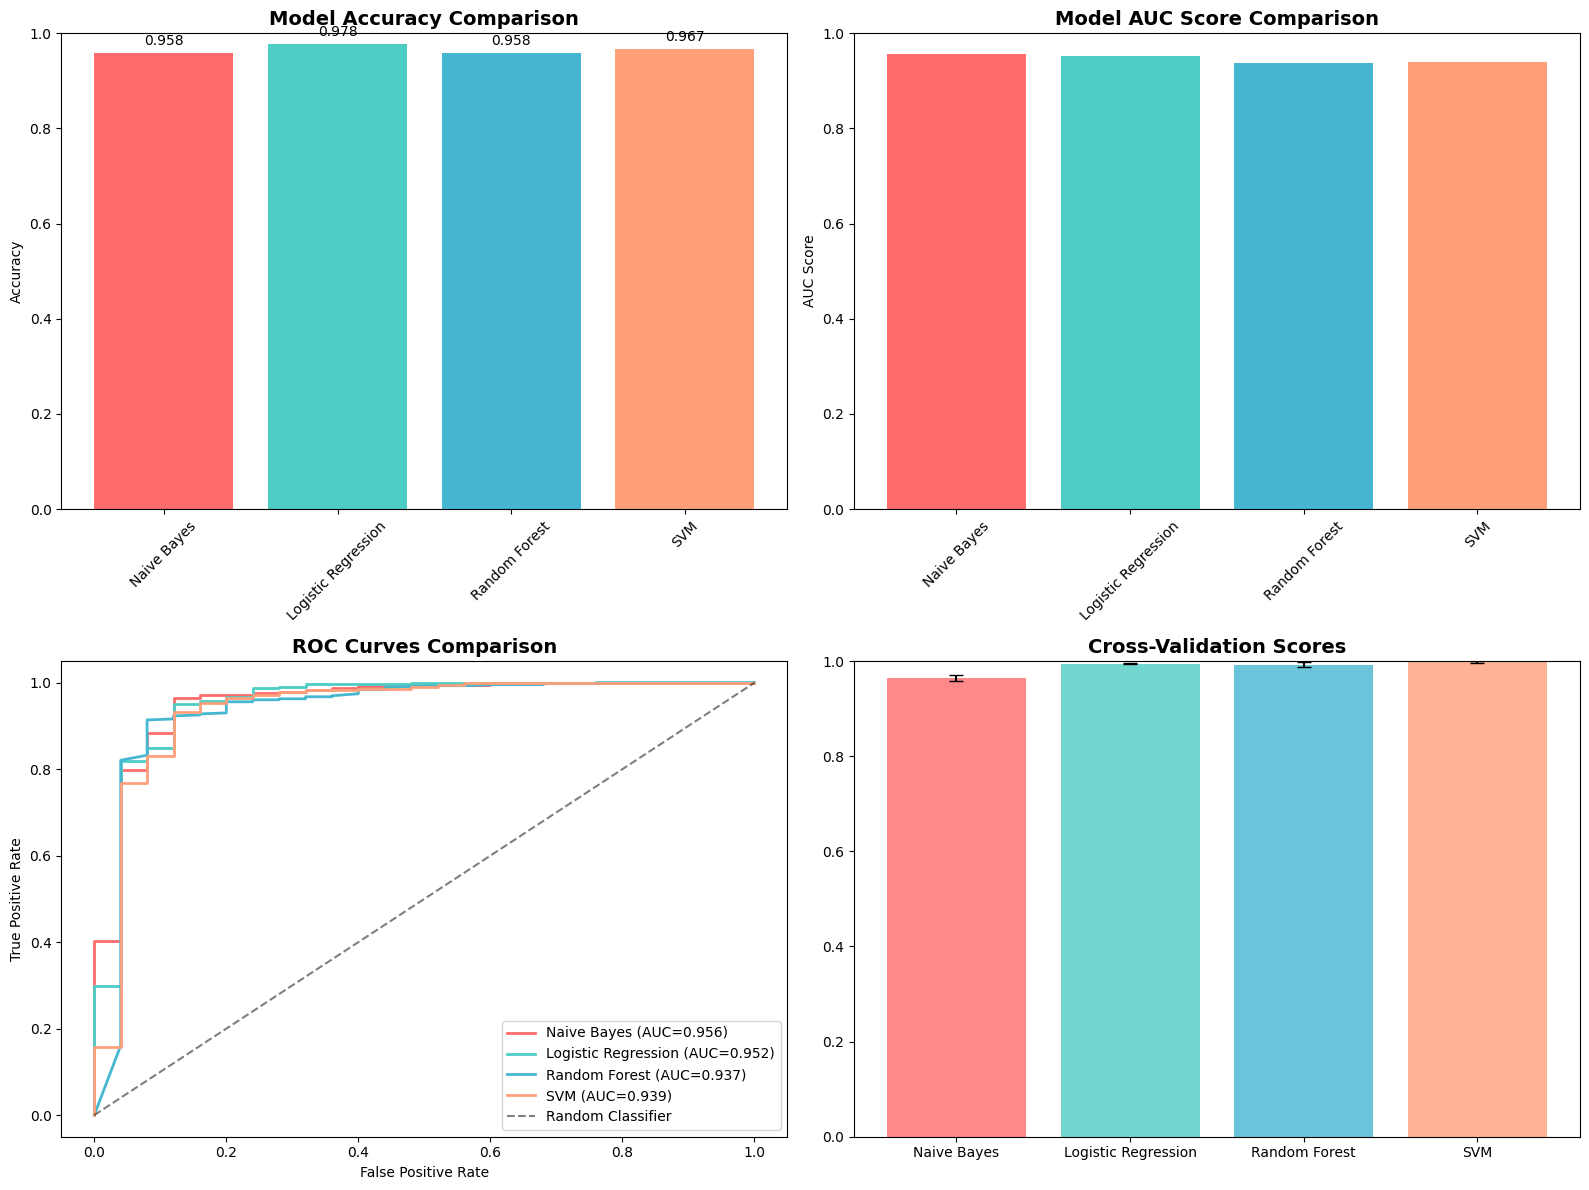

In [18]:
if results and len(results) > 0:
    # Performance comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    models_names = list(results.keys())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    # 1. Accuracy comparison
    accuracies = [results[model]['accuracy'] for model in models_names]
    bars1 = axes[0,0].bar(models_names, accuracies, color=colors[:len(models_names)])
    axes[0,0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].set_ylim(0, 1)

    # Add labels on bars
    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{acc:.3f}', ha='center', va='bottom')

    # 2. AUC Score comparison
    auc_scores = [results[model]['auc_score'] for model in models_names]
    bars2 = axes[0,1].bar(models_names, auc_scores, color=colors[:len(models_names)])
    axes[0,1].set_title('Model AUC Score Comparison', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('AUC Score')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].set_ylim(0, 1)

    # 3. ROC Curves
    for i, name in enumerate(models_names):
        try:
            fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
            axes[1,0].plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} (AUC={results[name]['auc_score']:.3f})")
        except: continue
    axes[1,0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    axes[1,0].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('False Positive Rate')
    axes[1,0].set_ylabel('True Positive Rate')
    axes[1,0].legend(loc='lower right')

    # 4. Cross-Validation scores
    cv_means = [results[model]['cv_mean'] for model in models_names]
    cv_stds = [results[model]['cv_std'] for model in models_names]
    bars3 = axes[1,1].bar(models_names, cv_means, yerr=cv_stds, capsize=5, color=colors[:len(models_names)], alpha=0.8)
    axes[1,1].set_title('Cross-Validation Scores', fontsize=14, fontweight='bold')
    axes[1,1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No results available for visualization")

In [19]:
import os
import joblib

# 1. Sabse pehle 'models' folder create karein agar nahi bana hai
os.makedirs("models", exist_ok=True)

# 2. Safety variables setup karein
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"🎯 Accuracy : {results[best_model_name]['accuracy']:.4f}")
vectorizer_ready = 'tfidf_vectorizer' in globals() or 'tfidf_vectorizer' in locals()

# 3. Agar 'best_model' memory me nahi hai, toh use variables se extract karne ki koshish karein
if best_model is None:
    if 'results' in globals() and 'trained_models' in globals() and results and trained_models:
        best_model_name = max(results, key=lambda x: results[x]['accuracy'])
        best_model = trained_models[best_model_name]
        print(f"🤖 Extracted Best Model from memory: {best_model_name}")
    elif 'results' in locals() and 'trained_models' in locals() and results and trained_models:
        best_model_name = max(results, key=lambda x: results[x]['accuracy'])
        best_model = trained_models[best_model_name]
        print(f"🤖 Extracted Best Model from local scope: {best_model_name}")
    elif os.path.exists("models/best_fake_news_model.pkl"):
        best_model = joblib.load("models/best_fake_news_model.pkl")
        print("💾 Existing model loaded from storage path.")

# 4. Final step: Agar model aur vectorizer mil gaye hain, toh unhe save (serialize) karein
if best_model is not None and vectorizer_ready:
    # Save the absolute trained best model binary
    joblib.dump(best_model, "models/best_fake_news_model.pkl")
    
    # Get vectorizer object dynamically from available runtime scope
    active_vectorizer = globals().get('tfidf_vectorizer', locals().get('tfidf_vectorizer'))
    joblib.dump(active_vectorizer, "models/tfidf_vectorizer.pkl")
    
    print("\n✅ SUCCESS: Model and TF-IDF Vectorizer Saved Successfully in 'models/' folder!")
else:
    print("\n❌ ERROR: Saving Failed!")
    if best_model is None:
        print("➡️ Reason: 'best_model' could not be found or extracted. Please execute your training cells first.")
    if not vectorizer_ready:
        print("➡️ Reason: 'tfidf_vectorizer' is not found anywhere in the active context environment.")


🏆 Best Model: Logistic Regression
🎯 Accuracy : 0.9780

✅ SUCCESS: Model and TF-IDF Vectorizer Saved Successfully in 'models/' folder!


In [20]:
print(results.keys())
print(trained_models.keys())

import os

print(os.path.exists("models/best_fake_news_model.pkl"))
print(os.path.exists("models/tfidf_vectorizer.pkl"))

dict_keys(['Naive Bayes', 'Logistic Regression', 'Random Forest', 'SVM'])
dict_keys(['Naive Bayes', 'Logistic Regression', 'Random Forest', 'SVM'])
True
True
